# Linear Theta Analysis of XY Tests at LBL petal0 on Jan 2026

This notebook is archived on github [here](https://github.com/desihub/fpoffline/blob/main/nb/LinThetaAnalysis)

use "DESI master" kernel

### Imports

In [3]:
import pathlib
import warnings
import json

In [4]:
import numpy as np
import matplotlib.pyplot as plt

In [5]:
import pandas as pd
pd.set_option('display.max_colwidth', 100)

In [6]:
import scipy.optimize
import scipy.stats

In [7]:
from astropy.table import Table

In [8]:
import desimeter.transform.pos2ptl
import desimeter.transform.ptl2fp

## Calibration

Load the calibration parameters to use. The CSV file was created using
```
cd ~fpa_expert/dkirkby
./getdata.py --calib calib-20260303.csv
```
which was run on 20260303.

After running with scales set from 339997, get the updated calib using:
```
./getdata.py --calib calib-20260303-2.csv
```

In [9]:
PETAL_ID_MAP = [4, 5, 6, 3, 8, 10, 11, 2, 7, 9]
PETAL_LOC_MAP = np.full(np.max(PETAL_ID_MAP)+1, -1, dtype=int)
PETAL_LOC_MAP[PETAL_ID_MAP] = np.arange(10)
print('PETAL_ID_MAP:', PETAL_ID_MAP)
print('PETAL_LOC_MAP:', PETAL_LOC_MAP)

PETAL_ID_MAP: [4, 5, 6, 3, 8, 10, 11, 2, 7, 9]
PETAL_LOC_MAP: [-1 -1  7  3  0  1  2  8  4  9  5  6]


In [10]:
def load_calib(name):
    calib = pd.read_csv(name, index_col='pos_id')
    lintheta = (calib.zeno_motor_t == True) & (calib.device_classified_nonfunctional == False)
    nlintheta = np.count_nonzero(lintheta)
    print(f'Found {nlintheta} linear theta positions in {name}')
    calib['petal_loc'] = PETAL_LOC_MAP[calib.petal_id]
    scales = calib[lintheta][['petal_loc','sz_ccw_t','sz_cw_t']].copy()
    return calib, scales

In [11]:
C, scales = load_calib('calib-20260303.csv')

Found 295 linear theta positions in calib-20260303.csv


In [12]:
C, scales2 = load_calib('calib-20260303-2.csv') # after analyzing 339997 to set scales

Found 295 linear theta positions in calib-20260303-2.csv


## CAN Errors

In [55]:
bad_can = [
    'M07499', # P0 can32
    'M07525', # P0 can34
    'M05445', # P1 can33
    'M05084', # P1 can48
    'M05361', # P3 can31
    'M04451', # P3 can38
    'M03786', # P3 can46
    'M01497', # P5 can34
    'M06601', # P6 can31
    'M07873', 'M07888', # P6 can34
    'M03232', # P7 can39
    'M03508', # P7 can48
    'M03568', # P7 can49
    'M03230', # P8 can40
    'M04083'  # P9 can34
]
assert np.all(np.isin(bad_can, C.index)), 'Some bad_can pos_ids not found in calib'
print(f'Identified {len(bad_can)} bad CAN devices')
print(','.join(bad_can))

Identified 16 bad CAN devices
M07499,M07525,M05445,M05084,M05361,M04451,M03786,M01497,M06601,M07873,M07888,M03232,M03508,M03568,M03230,M04083


## Move Data

Load data from the positioner moves DB for a single exposure.  Most columns are straight from the [database schema](https://docs.google.com/spreadsheets/d/1e8yyjNFI9nCOT_KsJAxI3uzl8qSKqhuiDVXtXvxHNqM/edit#gid=836120262), with the following additions:
 - dx, dy: measured OBS_X,Y of stationary robots relative to the average over all iterations for a single exposure, in microns. Moving robots have NaN values here.
 - dx_turb, dy_turb: estimated turbulence corrections derived from a Gaussian process model, in microns. Equal to dx, dy for stationary robots.

To get this data, login to beyonce and extract DB moves (from `~dkirkby`):
```
./getdata.py --site petal0 --start "2024-02-24 03:15:00+00:00" --stop "2024-02-24 05:30:00+00:00"
```
but of course change the start and stop times to match the sequence you're downloading moves for.

Files will be saved in `~/dkirkby/moves/moves-{expid}.csv`, so you'll need to know the expid from petal0

In [14]:
def load_moves(expid, path='moves', pat='moves-{expid}.csv', petals=None):
    name = pathlib.Path(path) / pat.format(expid=expid)
    moves = pd.read_csv(name, parse_dates=['time_recorded'], low_memory=False)
    if petals is not None:
        sel = np.isin(moves.location // 1000, petals)
        print(f'Keeping {np.count_nonzero(sel)} / {len(sel)} moves in petals {petals}')
        moves = moves[sel]
    niter = len(np.unique(moves.exposure_iter))
    print(f'Read {niter} exposure iterations')
    return moves

Load getdata results:

In [16]:
#moves94 = load_moves(339994)
moves97 = load_moves(339997)
moves98 = load_moves(339998)

Read 58 exposure iterations
Read 58 exposure iterations


## XY Grid Analysis

In [17]:
def extract_fields(moves, colname, key, delims='()'):

    if key.endswith('TP'):
        subkeys = ('T', 'P')
    elif key.endswith('XYZ'):
        subkeys = ('X', 'Y', 'Z')
    elif key.endswith('XY'):
        subkeys = ('X', 'Y')
    elif key.endswith('dXdY'):
        subkeys = ('dX', 'dY')
    else:
        subkeys = ()

    start = f'{key}'
    if subkeys:
        start += f'={delims[0]}'
        stop = delims[1]
    else:
        stop = ';'

    if start.endswith('SCALE_A'):
        start += '='

    def extract(note):
        i1 = note.index(start)
        try:
            i2 = note.index(stop, i1)
        except ValueError:
            i2 = len(note)
        values = note[i1 + len(start):i2]
        if subkeys:
            return [float(value) for value in values.split(',')]
        else:
            return float(values)

    sel = moves[colname].notna() & moves[colname].str.contains(key)
    extracted = moves.loc[sel, colname].apply(extract)

    if subkeys:
        key = key[:-len(''.join(subkeys))]
        for k, subkey in enumerate(subkeys):
            col = f'{key}_{subkey}'
            moves[col] = np.nan
            moves.loc[sel, col] = extracted.apply(lambda v: v[k])
    else:
        moves[key] = np.nan
        moves.loc[sel, key] = extracted

    return moves

In [18]:
def ptl2int(x_ptl, y_ptl, offset_x, offset_y, length_r1, length_r2, offset_t, offset_p, t_int_guess=None):
    """Transform from ptl (x,y) to internal angles (t,p).
    """
    x_flat, y_flat = desimeter.transform.pos2ptl.ptl2flat(x_ptl, y_ptl)
    x_loc = desimeter.transform.pos2ptl.flat2loc(x_flat, offset_x)
    y_loc = desimeter.transform.pos2ptl.flat2loc(y_flat, offset_y)
    t_int, p_int, unreachable = desimeter.transform.pos2ptl.loc2int(
        x_loc, y_loc, length_r1, length_r2, offset_t, offset_p,
        t_int_guess=t_int_guess, t_guess_tol=90)
    if np.any(unreachable):
        warnings.warn(f'{np.count_nonzero(unreachable)} / {len(unreachable)} unreachable')
    return x_loc, y_loc, t_int, p_int

In [19]:
def pproc_xy(moves, calib):

    # Define calibration lookup function
    getcalib = lambda name: calib.loc[moves.pos_id, name].to_numpy()

    # Extract fields from the log_note column
    extract_fields(moves, 'log_note', 'submove')
    extract_fields(moves, 'log_note', 'req_posintTP')
    extract_fields(moves, 'log_note', 'req_ptlXYZ')
    extract_fields(moves, 'log_note', 'tCCW_SCALE_A')
    extract_fields(moves, 'log_note', 'tCW_SCALE_A')

    # Extract fields from the move_cmd column
    extract_fields(moves, 'move_cmd', 'poslocdXdY', delims='[]')  # only present for submove 1

    # Calculate and save the sum of commanded T,P moves from the moves_valN columns
    def sum_move(col_in, col_out):
        moves[col_out] = 0.
        valid = moves[col_in].notna()
        angle = moves[col_in].dropna().str.split('; | ').apply(
            lambda d: np.sum(np.array(list(map(float, d[1::2])))))
        moves.loc[valid, col_out] = angle
        #moves.drop(columns=col_in, inplace=True) # Drop the original string column
    sum_move('move_val1', 'req_dt')
    sum_move('move_val2', 'req_dp')

    # Calculate internal T,P angles from the FVC-measured ptl X,Y
    x_ptl, y_ptl = moves.ptl_x.to_numpy(), moves.ptl_y.to_numpy()
    x_loc, y_loc, t_int, p_int = ptl2int(
        x_ptl, y_ptl,
        getcalib('offset_x'), getcalib('offset_y'),
        getcalib('length_r1'), getcalib('length_r2'),
        getcalib('offset_t'), getcalib('offset_p'),
        t_int_guess=moves.pos_t.to_numpy())

    # Check if we need to add/subtract 360 deg to internal theta to avoid wrap around.
    range_t = getcalib('physical_range_t')
    alpha = (range_t - 360) / 2
    lo_wrap = (t_int < -180 + alpha) & (moves.pos_t > 180 - alpha)
    hi_wrap = (t_int > 180 - alpha) & (moves.pos_t < -180 + alpha)
    t_int[lo_wrap] += 360
    t_int[hi_wrap] -= 360
    moves['lo_wrap'] = lo_wrap
    moves['hi_wrap'] = hi_wrap

    moves['fvc_t'] = t_int
    moves['fvc_p'] = p_int
    moves['fvc_loc_x'] = x_loc
    moves['fvc_loc_y'] = y_loc

    # Calculate the changes in angles between moves based on FVC spots
    byloc = moves.groupby('location')
    moves['last_t'] = byloc.fvc_t.shift(+1, fill_value=np.nan)
    moves['last_p'] = byloc.fvc_p.shift(+1, fill_value=np.nan)
    moves['act_dt'] = moves.fvc_t - moves.last_t
    moves['act_dp'] = moves.fvc_p - moves.last_p

In [20]:
pproc_xy(moves97, C)

/var/folders/nd/zsy2rjs94b3dvxl5jn565vxm0000gn/T/ipykernel_10334/1145533206.py:11: UserWarning: 174 / 288782 unreachable
  warnings.warn(f'{np.count_nonzero(unreachable)} / {len(unreachable)} unreachable')


In [21]:
pproc_xy(moves98, C)

/var/folders/nd/zsy2rjs94b3dvxl5jn565vxm0000gn/T/ipykernel_10334/1145533206.py:11: UserWarning: 174 / 288782 unreachable
  warnings.warn(f'{np.count_nonzero(unreachable)} / {len(unreachable)} unreachable')


## Plots

In [70]:
moves98.columns

Index(['time_recorded', 'device_loc', 'pos_id', 'pos_t', 'pos_p',
       'ctrl_enabled', 'move_cmd', 'move_val1', 'move_val2', 'log_note',
       'exposure_id', 'exposure_iter', 'flags', 'ptl_x', 'ptl_y', 'obs_x',
       'obs_y', 'location', 'submove', 'req_posint_T', 'req_posint_P',
       'req_ptl_X', 'req_ptl_Y', 'req_ptl_Z', 'tCCW_SCALE_A', 'tCW_SCALE_A',
       'posloc_dX', 'posloc_dY', 'req_dt', 'req_dp', 'lo_wrap', 'hi_wrap',
       'fvc_t', 'fvc_p', 'fvc_loc_x', 'fvc_loc_y', 'last_t', 'last_p',
       'act_dt', 'act_dp'],
      dtype='object')

In [94]:
def plot_xy(moves, calib, pos_id='M03935', size_mm=4, scales=(0,0), path=None, max_iter=50):

    motor = 'theta'

    M = moves[moves.pos_id == pos_id]

    off = np.all(~M.ctrl_enabled)
    if off:
        print(f'Skipping {pos_id} because ctrl_enabled is always False')
        return pos_id, np.nan, np.nan, np.nan, False, np.nan, np.nan, np.nan

    #print(M)
    cal = calib.loc[pos_id]
    # Lookup arm lengths in mm
    r1 = cal.length_r1
    r2 = cal.length_r2
    # Lookup hole center in flat_XY coords
    xc_calib = cal.offset_x
    yc_calib = cal.offset_y
    # Lookup theta hardstops
    physical_range_t = cal.physical_range_t
    offset_t = cal.offset_t
    ambiguity_size = physical_range_t - 360
    tlim1 = physical_range_t / 2 - ambiguity_size
    tlim2 = physical_range_t / 2
    # Convert to ptl_XY coords
    xc_calib, yc_calib = desimeter.transform.pos2ptl.flat2ptl(xc_calib, yc_calib)

    #PLOT
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.subplots_adjust(left=0.05, right=0.99, bottom=0.05, top=0.99, wspace=0.2, hspace=0.1)

    # 2D plot in LOC_X,Y
    ax = axes[0,0]
    ax.set(aspect=1, xlabel='poslocX [mm]', ylabel='poslocY [mm]',
          xlim=(-size_mm, +size_mm), ylim=(-size_mm, +size_mm))
    ax.text(0.05, 0.95, f'{pos_id} r1={r1:.1f}mm r2={r2:.1f}mm', transform=ax.transAxes)

    I0 = M.submove == 0
    I1 = M.submove == 1
    ax.scatter(M.fvc_loc_x[I0], M.fvc_loc_y[I0], c=M.exposure_iter[I0], lw=0.5, edgecolor='k', cmap='Blues', s=50, marker='o', label='submove 0')
    ax.scatter(M.fvc_loc_x[I1], M.fvc_loc_y[I1], c='none', lw=0.5, edgecolor='k', s=50, marker='s', label='submove 1')
    ax.plot(M.fvc_loc_x, M.fvc_loc_y, 'b-', lw=1, alpha=0.2)
    ax.plot(0, 0, 'rx')
    ax.legend(loc='lower right', fontsize=8, ncol=1)

    # Phi vs exposure iteration
    ax = axes[0,1]
    ax.set(xlabel='Exposure Iter', ylabel='poslocP [deg]', ylim=(0,200))
    ax.grid(which='major', color='lightgray', linestyle=':', axis='y')
    ax.scatter(M.exposure_iter[I0], M.fvc_p[I0], c=M.exposure_iter[I0], lw=0.5, edgecolor='k', cmap='Blues', s=50, marker='o', label='submove 0')
    ax.scatter(M.exposure_iter[I1], M.fvc_p[I1], c='none', lw=0.5, edgecolor='k', s=50, marker='s', label='submove 1')
    ax.plot(M.exposure_iter, M.fvc_p, 'b-', lw=1, alpha=0.2)
    ax.plot(M.exposure_iter, M.req_posint_P, 'r.', ms=3, label='request')
    ax.legend(loc='lower right', fontsize=8, ncol=3)

    # Check if theta is stuck at a hardstop.
    t_lo, t_med, t_hi = np.percentile(M.fvc_t, (0, 50, 100))
    if t_hi - t_lo < 2:
        s = np.sign(t_med)
        # Calculate signed distance from the hardstop with the same sign as t_med
        toffset2 = t_med - s * tlim2
        # Calculate signed distance from the hardstop with the opposite sign as t_med
        toffset1 = t_med - s * tlim1
        #print(f'WARNING: {pos_id} theta appears to be stuck at {t_med:.1f} deg (offsets {toffset1:.1f}, {toffset2:.1f} deg)')
        stuck = True
    else:
        toffset2, toffset1 = 0, 0
        stuck = False

    # Theta vs exposure iteration
    ax = axes[1,1]
    #lim = (np.min(M.fvc_t)-30, np.max(M.fvc_t)+20)
    ax.set(xlabel='Exposure Iter', ylabel='poslocT [deg]', ylim=(-205,205))
    ax.grid(which='major', color='lightgray', linestyle=':', axis='y')
    for s in (-1, +1):
        ax.axhspan(s * tlim1, s * tlim2, color='r', alpha=0.1)
    if stuck:
        ax.axhline(t_med, color='r', lw=2, alpha=0.5)
    ax.scatter(M.exposure_iter[I0], M.fvc_t[I0], c=M.exposure_iter[I0], lw=0.5, edgecolor='k', cmap='Blues', s=50, marker='o', label='submove 0')
    ax.scatter(M.exposure_iter[I1], M.fvc_t[I1], c='none', lw=0.5, edgecolor='k', s=50, marker='s', label='submove 1')
    ax.plot(M.exposure_iter, M.fvc_t, 'b-', lw=1, alpha=0.2)
    ax.plot(M.exposure_iter, M.req_posint_T, 'r.', ms=3, label='request')
    ax.legend(loc='lower right', fontsize=8, ncol=3)

    # Requested vs actual delta(theta) for each submove
    for submove in (0,1):
        sel = (M.submove == submove)
        Msel = M[sel]
        use =  (Msel.exposure_iter <= max_iter)
        req, act = np.array(Msel.req_dt), np.array(Msel.act_dt)

        cut = 300
        wrap_hi = (act - req > cut)
        wrap_lo = (act - req < -cut)
        act[wrap_hi] -= 360
        act[wrap_lo] += 360

        xlabel = 'Requested dT [deg]'
        ylabel = 'Actual dT [deg]'
        lim = [360,65][submove]
        ax = axes[submove, 2]

        if submove == 1:
            # Measure quality of correction moves for iter <= max_iter
            big_enough = np.abs(req) > 5
            if np.any(big_enough & use):
                slope = max(0.2, np.median(act[big_enough & use] / req[big_enough & use]))
            else:
                slope = 1
            alpha = 0.05 # slope fractional error
            delta = 4 # abs error in deg
            bad = (np.abs(act - slope * req) > alpha * np.abs(req) + delta) & use
            ax.plot([-lim,0,lim], [-lim*slope*(1+alpha)-delta, -delta, lim*slope*(1-alpha)-delta], 'm-', lw=2, alpha=0.5)
            ax.plot([-lim,0,lim], [-lim*slope*(1-alpha)+delta, +delta, lim*slope*(1+alpha)+delta], 'm-', lw=2, alpha=0.5)

        ax.set(aspect=1, xlim=(-lim,lim), ylim=(-lim,lim), xlabel=xlabel, ylabel=ylabel)
        ax.text(0.05, 0.95, f'{pos_id}\nCW / CCW={scales[0]:.3f} / {scales[1]:.3f}\nsubmove {submove}', va='top', transform=ax.transAxes)
        ax.grid(linestyle=':')
        ax.plot([-lim,lim],[-lim,lim], 'r--', lw=0.5, alpha=0.5)
        ax.plot([-lim,lim],[-lim-360,lim-360], 'r--', lw=0.5, alpha=0.5)
        ax.plot([-lim,lim],[-lim+360,lim+360], 'r--', lw=0.5, alpha=0.5)
        ax.plot(req[use], act[use], '.')
        ax.plot(req[~use], act[~use], 'c+')
        if submove == 1:
            ax.plot(req[bad], act[bad], 'rx', ms=10)
            if np.any(use):
                bad_frac = np.count_nonzero(bad) / np.count_nonzero(use)
            else:
                bad_frac = 1.0
            ax.text(0.95, 0.05, f'{np.count_nonzero(bad)} / {np.count_nonzero(use)} bad = {bad_frac:.1%}',
                    va='bottom', ha='right', color='r', transform=ax.transAxes)

    # Get blind move residuals from posloc_dXY in the move_cmd of the correction move
    dx0 = 1e3 * M.posloc_dX[I1]
    dy0 = 1e3 * M.posloc_dY[I1]
    dr0 = np.hypot(dx0, dy0)

    ax = axes[1,0]
    #'''
    bins = np.linspace(0, 250, 51)
    ax.set(xlabel='Positioning error [microns]', xlim=(bins[0], bins[-1]))
    ax.hist(dr0, bins=bins, histtype='step', hatch='/', label='Blind Move')
    ax.legend()

    # Calculate and display statistics
    if len(dr0) == 0:
        blindErrMax = np.nan
        blindErr95 = np.nan
    else:
        blindErrMax = np.max(dr0)
        blindErr95 = np.nanpercentile(dr0, 95)
    label = f'MAX blind: 100% < {blindErrMax:.1f}um 95% < {blindErr95:.1f}um\n'
    ax.text(0.95, 0.5, label, va='center', ha='right', transform=ax.transAxes)

    if path is not None:
        plt.savefig(f'{path}/{pos_id}.jpg')

    return pos_id, blindErrMax, blindErr95, bad_frac, stuck, t_med, toffset1, toffset2

('M03122',
 3094.0252882554655,
 2930.071891491784,
 0.68,
 True,
 155.30616369796653,
 -8.511677654388961,
 -40.87599494967799)

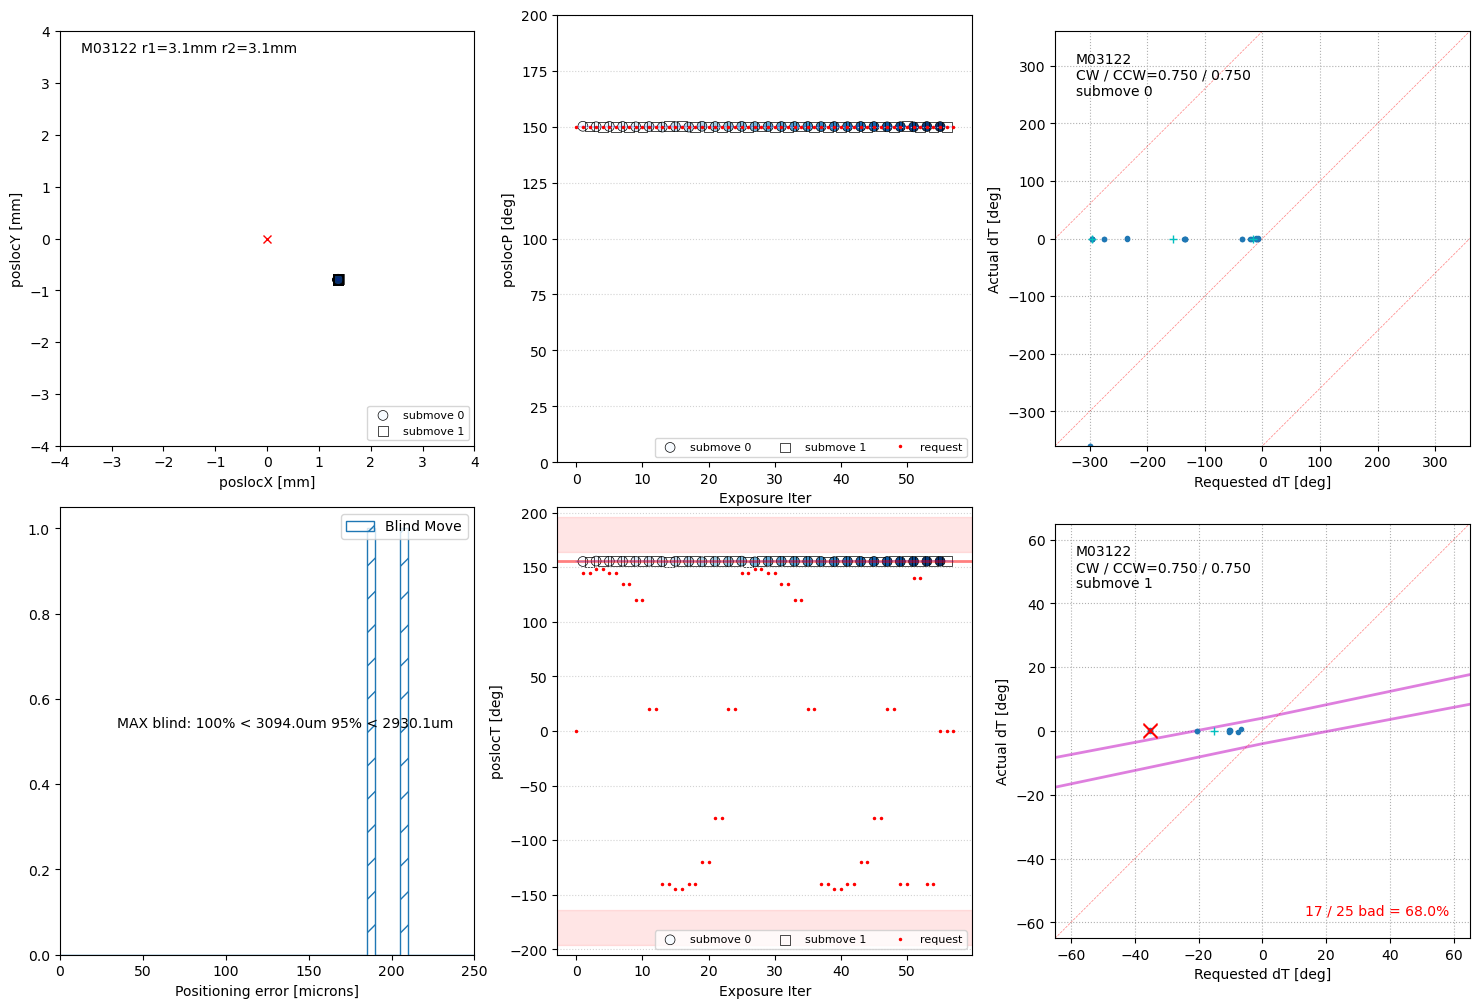

In [95]:
plot_xy(moves98, C, pos_id='M03122', scales=(0.75,0.75), path='plots/dev')

In [74]:
def plot_all(scales, moves, path):
    if not pathlib.Path(path).exists():
        pathlib.Path(path).mkdir(parents=True)
    rows = [ ]
    posids = scales.index.to_numpy()
    for posid in posids:
        try:
            row = scales.loc[posid]
            ccw, cw = row.sz_ccw_t, row.sz_cw_t
            rows.append(plot_xy(moves, C, posid, scales=(cw, ccw), path=path))
        except Exception as e:
            print(posid, 'ERROR:', e)
        plt.clf()
        plt.close()
    stats = pd.DataFrame(rows, columns=('posid', 'blindMax', 'blind95','bad_frac', 'stuck', 't_med', 'toffset1', 'toffset2'))
    stats.set_index('posid', inplace=True)
    return stats

In [75]:
stats = plot_all(scales, moves97, 'plots/339997/')

Found 65/295 bad positions with bad_frac > 24.0%
M07499,M07525,M07843,M04635,M05831,M07364,M03784,M05084,M04711,M05445,M05570,M02763,M03292,M05961,M06345,M05970,M03075,M03191,M03469,M03478,M04064,M03186,M04595,M04497,M04601,M05013,M04641,M03009,M04749,M06982,M08474,M08221,M03307,M06601,M07505,M01768,M04722,M03061,M03688,M03289,M03242,M03296,M03408,M04712,M03148,M03686,M03232,M05960,M02733,M04801,M05515,M03226,M02474,M05203,M02567,M03230,M05179,M03356,M04083,M02128,M07688,M07623,M07271,M02273,M07695


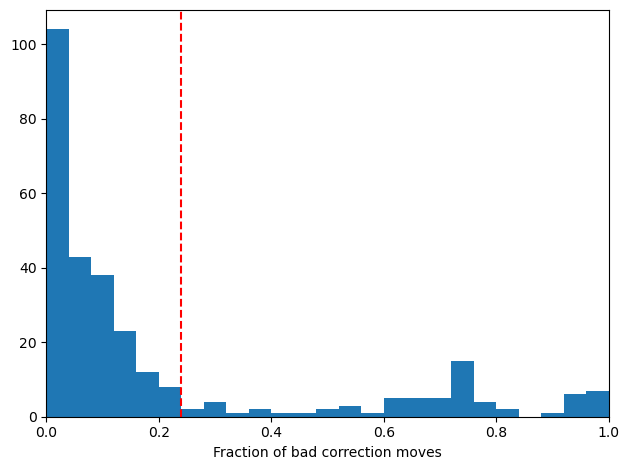

In [76]:
def find_bad(stats, threshold=0.24):
    bfrac = stats.bad_frac.to_numpy()
    bfrac[bfrac >= 1] = 1 - 1e-6
    plt.hist(bfrac, bins=np.linspace(0,1,26))
    plt.axvline(threshold, color='r', ls='--')
    plt.xlim(0, 1)
    plt.xlabel('Fraction of bad correction moves')
    nbad = np.count_nonzero(bfrac > threshold)
    print(f'Found {nbad}/{len(bfrac)} bad positions with bad_frac > {threshold:.1%}')
    bad_ids = stats.index[bfrac > threshold].to_list()
    print(','.join(bad_ids))
    plt.tight_layout()
    plt.savefig('bad_frac_hist.jpg')
    return bad_ids

bad_ids = find_bad(stats)

In [90]:
both_ids = list(set(bad_ids) & set(bad_can))
print(','.join(both_ids))

M07499,M05445,M07525,M03232,M06601,M05084,M03230,M04083


In [96]:
stats2 = plot_all(scales2, moves98, 'plots/339998/')

Skipping M05445 because ctrl_enabled is always False
Skipping M03703 because ctrl_enabled is always False
Skipping M05084 because ctrl_enabled is always False
Skipping M07888 because ctrl_enabled is always False
Skipping M03232 because ctrl_enabled is always False
Skipping M03568 because ctrl_enabled is always False
Skipping M04083 because ctrl_enabled is always False
Skipping M03230 because ctrl_enabled is always False


In [ ]:
stuck_lo = [
    # 14 positioners
    'M02767','M03346','M03112','M08015','M07737','M03287','M05264','M03710','M04547','M03261','M03334','M03285','M03446','M03630'
]
stuck_hi = [
    # 1 positioner
    'M03122'
]

In [91]:
','.join(stuck_lo)

'M02767,M03346,M03112,M08015,M08015,M07737,M03287,M05264,M03710,M04547,M03261,M03334,M03285,M03446,M03630'

In [161]:
def update_calib(stats=stats2):
    bad = np.isin(stats.index, bad_ids)
    bad2 = np.isin(stats.index, bad_can)
    stats = stats[stats.stuck & ~bad & ~bad2]
    lo = np.isin(stats.index, stuck_lo)
    hi = np.isin(stats.index, stuck_hi)
    stats = stats[lo | hi]

    updates = [ ]

    posids = stats.index.to_list()

    getcalib = lambda name: C.loc[posids, name].to_numpy()
    offset_t = getcalib('offset_t')
    physical_range_t = getcalib('physical_range_t')

    for k, posid in enumerate(posids):
        intT = stats.t_med[k]
        dT = stats.toffset1[k]
        s = np.sign(intT)
        updates.append(dict(POS_ID=posid, POS_T=intT - dT - s * 360, OFFSET_T=offset_t[k] + dT, COMMIT_POS_T=True, COMMIT_OFFSET_T=True))
        print(f'{k:2d} {posid} offset_t={offset_t[k]:6.1f} physical_range_t={physical_range_t[k]:6.1f} t_med={stats.t_med[k]:6.1f} toffset1={stats.toffset1[k]:6.1f}')

    df = pd.DataFrame(updates).round(2)
    df.to_csv('lintheta-fix-wraps.csv', index=False)

    return df

update_calib()

 0 M02767 offset_t= 168.3 physical_range_t= 391.4 t_med=-153.8 toffset1=  10.5
 1 M03346 offset_t=-114.2 physical_range_t= 390.4 t_med=-164.2 toffset1=   0.6
 2 M03112 offset_t= 144.6 physical_range_t= 392.8 t_med=-162.0 toffset1=   1.6
 3 M08015 offset_t= 176.5 physical_range_t= 393.4 t_med=-159.3 toffset1=   3.9
 4 M07737 offset_t=  96.3 physical_range_t= 390.6 t_med=-162.1 toffset1=   2.6
 5 M03122 offset_t= 100.6 physical_range_t= 392.4 t_med= 155.3 toffset1=  -8.5
 6 M03287 offset_t= 163.4 physical_range_t= 394.0 t_med=-161.2 toffset1=   1.9
 7 M05264 offset_t=  32.8 physical_range_t= 394.5 t_med=-144.0 toffset1=  18.8
 8 M03710 offset_t=-119.4 physical_range_t= 392.7 t_med=-154.5 toffset1=   9.1
 9 M04547 offset_t=  15.6 physical_range_t= 393.5 t_med=-152.5 toffset1=  10.7
10 M03261 offset_t= 101.6 physical_range_t= 392.0 t_med=-162.3 toffset1=   1.7
11 M03334 offset_t= -70.0 physical_range_t= 388.9 t_med=-153.8 toffset1=  11.7
12 M03285 offset_t= -63.9 physical_range_t= 390.9 t_

,POS_ID,POS_T,OFFSET_T,COMMIT_POS_T,COMMIT_OFFSET_T
0,M02767,195.71,178.76,True,True
1,M03346,195.18,-113.65,True,True
2,M03112,196.39,146.20,True,True
3,M08015,196.72,180.47,True,True
4,M07737,195.32,98.87,True,True
5,M03122,-196.18,92.05,True,True
6,M03287,196.99,165.23,True,True
7,M05264,197.23,51.60,True,True
8,M03710,196.35,-110.25,True,True
9,M04547,196.77,26.24,True,True


In [84]:
def save_xy(moves, scales, stats, fit=False, save='moves.json', motor = 'phi'):

    assert motor in ['phi', 'theta']

    data = { }
    posids = scales.index.to_numpy()
    ##f = open('mar24-updated.csv', 'w')
    ##print('posid,cw,ccw', file=f)
    for posid in posids:
        if posid not in scales.index:
            continue
        scale = scales.loc[posid]
        appliedScaleCW = scale.sz_cw_t
        appliedScaleCCW = scale.sz_ccw_t
        petal_loc = scale.petal_loc

        if not posid in stats.index:
            continue
        stat = stats.loc[posid]

        if motor == 'phi':
            M = moves[(moves.pos_id == posid) & moves.act_dp.notna() & moves.submove.notna() & (moves.req_dp != 0)]
        if motor == 'theta':
            M = moves[(moves.pos_id == posid) & moves.act_dt.notna() & moves.submove.notna() & (moves.req_dt != 0)]

        if fit:
            try:
                if motor == 'phi':
                    finalParameters, initialNLP, finalNLP, predicted = fitLinearMotor(
                        M.req_dp, M.act_dp, appliedScaleCW, appliedScaleCCW)
                if motor == 'theta':
                    finalParameters, initialNLP, finalNLP, predicted = fitLinearMotor(
                        M.req_dt, M.act_dt, appliedScaleCW, appliedScaleCCW)
                S, dS, dC, dR = [float(x) for x in np.round(finalParameters,5)]
            except RuntimeError as e:
                print(f'Cannot fit {posid}: {e}')
                continue
        else:
            S = (appliedScaleCW + appliedScaleCCW) / 2
            dC = (appliedScaleCCW - appliedScaleCW) / 2
            dS = 0
            dR = 0

        info = dict(
            petal_loc=petal_loc,
            appliedCruiseScaleCW=appliedScaleCW, appliedCruiseScaleCCW=appliedScaleCCW,
            S=S, dS=dS, dC=dC, dR=dR,
            blindMax=nan2zero(stat.blindMax), blind95=nan2zero(stat.blind95)
            #corr30=stat.corr30, corr20=stat.corr20, corrRms=stat.corrRms
        )
        #'blindMax', 'blind95', 'corr30', 'corr20', 'corrRms'

        Ccw = S + dS - dC
        Cccw = S + dS + dC

        ##print(f'{posid} CW/CCW={Ccw:.2f}/{Cccw:.2f} S={S:.3f} dS={dS:.3f} dC={dC:.3f} dR={dR:.3f} corrRms={stat.corrRms:.1f}um')
        ##print(f'{posid},{Ccw:.4f},{Cccw:.4f}', file=f)

        sub = [int(x) for x in M.submove]
        if motor == 'phi':
            req = [float(x) for x in np.round(M.req_dp, 4)]
            act = [float(x) for x in np.round(M.act_dp, 4)]
        if motor == 'theta':
            req = [float(x) for x in np.round(M.req_dt, 4)]
            act = [float(x) for x in np.round(M.act_dt, 4)]
        info['moves'] = [ dict(sub=sub[i], req=req[i], act=act[i]) for i in range(len(M)) ]
        data[posid] = info

    ##f.close()
    with open(save, 'w') as f:
        json.dump(data, f, indent=2, allow_nan=False, default=lambda x: None)

#save_xy(moves226836, real_linphis, applied_scales)

In [83]:
def nan2zero(x):
    if np.isnan(x):
        return 0
    else:
        return x

In [67]:
save_xy(moves94, scales, stats, fit=False, save = '20260303-339994.json', motor='theta')

In [71]:
save_xy(moves97, scales, stats, fit=False, save = '20260303-339997.json', motor='theta')

In [85]:
save_xy(moves98, scales2, stats, fit=False, save = '20260303-339998.json', motor='theta')

## Selection of Viable Linear Thetas After First Test

In [124]:
def get_robots():

    initial = scales.index.to_list()
    final = list(set(initial) - set(bad_can) - set(bad_ids))
    print(f'selected {len(final)} robots after removing bad CAN devices and bad correction move devices')
    print(','.join(final))
    return final

final1_ids = get_robots()

selected 222 robots after removing bad CAN devices and bad correction move devices
M05556,M06185,M03199,M07934,M06861,M03349,M03084,M03133,M03126,M01750,M03392,M05264,M05119,M03379,M07498,M04775,M03427,M05027,M06038,M02718,M03874,M03334,M03285,M07912,M03446,M03769,M03060,M03327,M03281,M03501,M04065,M05530,M03506,M03104,M05952,M03771,M03293,M04169,M07955,M03268,M02767,M03256,M08143,M03624,M03037,M05967,M03528,M03659,M05322,M04834,M07801,M07747,M07093,M07403,M07427,M04547,M03594,M08347,M07238,M03287,M03712,M03405,M03538,M02720,M05398,M05857,M04199,M03016,M03336,M03322,M03668,M04843,M03361,M04882,M05353,M07507,M06667,M07251,M03646,M07092,M03429,M05495,M03600,M03564,M03219,M06811,M03067,M07158,M03008,M05612,M04499,M03348,M02848,M04085,M03452,M01020,M03112,M03026,M03163,M03319,M03683,M07460,M03346,M06651,M05328,M06818,M07502,M03321,M03555,M01697,M03610,M04515,M07367,M03558,M08015,M05723,M05143,M04507,M04161,M05762,M03694,M03719,M03377,M03254,M03119,M03330,M02723,M06666,M07591,M05940,M04493,

206 phi motor scales available
1 robots are both linear phi and theta
M04199


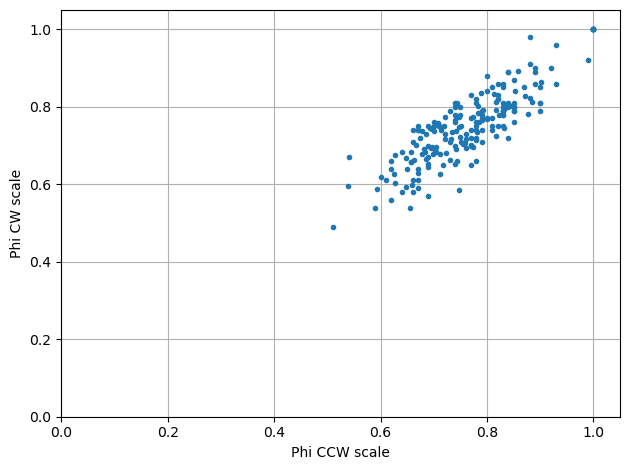

In [126]:
def plot_phi_scales():

    sel = C.zeno_motor_p & ~C.device_classified_nonfunctional
    print(np.count_nonzero(sel), 'phi motor scales available')
    phi_ids = C.index[sel].to_list()
    both_ids = list(set(phi_ids) & set(final1_ids))
    print(f'{len(both_ids)} robots are both linear phi and theta')
    print(','.join(both_ids))

    plt.plot(C[sel].sz_ccw_p, C[sel].sz_cw_p, '.')
    plt.xlim(0, 1.05)
    plt.ylim(0, 1.05)
    plt.xlabel('Phi CCW scale')
    plt.ylabel('Phi CW scale')
    plt.grid()
    plt.tight_layout()
    plt.savefig('final_scales_phi.jpg')
    return both_ids

dual_ids = plot_phi_scales()

Found 10 / 222 bad robots with both CW and CCW scale < 0.40
M03538,M03330,M07367,M05612,M03429,M04499,M03771,M03379,M03108,M03452


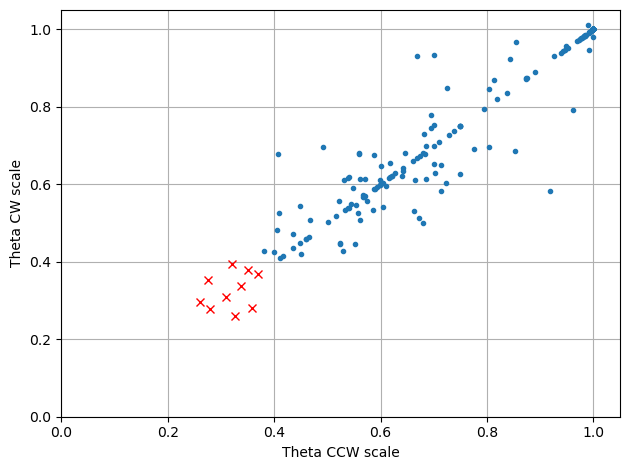

In [127]:
def plot_final_scales(cut=0.4):
    sel = np.isin(scales2.index, final1_ids)
    S = scales2[sel]
    bad = (S.sz_cw_t < cut) & (S.sz_ccw_t < cut)
    print(f'Found {np.count_nonzero(bad)} / {len(S)} bad robots with both CW and CCW scale < {cut:.2f}')
    bad_ids = S.index[bad].to_list()
    print(','.join(bad_ids))
    plt.plot(S[~bad].sz_ccw_t, S[~bad].sz_cw_t, '.')
    plt.plot(S[bad].sz_ccw_t, S[bad].sz_cw_t, 'rx')
    plt.xlim(0, 1.05)
    plt.ylim(0, 1.05)
    plt.xlabel('Theta CCW scale')
    plt.ylabel('Theta CW scale')
    plt.grid()
    plt.tight_layout()
    plt.savefig('final_scales.jpg')
    return bad_ids

bad_scale_ids = plot_final_scales()

In [144]:
def get_final():

    final = list(set(final1_ids) - set(bad_scale_ids) - set(dual_ids))
    print(f'selected {len(final)} final robots after removing bad scale and dual devices')
    print(','.join(final))
    return final

final_ids = get_final()

selected 211 final robots after removing bad scale and dual devices
M04507,M05556,M04161,M05762,M03694,M03719,M03199,M06185,M07934,M03377,M06861,M03254,M03349,M03084,M03119,M02723,M06666,M07591,M03133,M05940,M03126,M01750,M04493,M03871,M03392,M05264,M05119,M03235,M05143,M07498,M03122,M04775,M07547,M03778,M03427,M05027,M06038,M02718,M05928,M04661,M03874,M03086,M05471,M03552,M03334,M03285,M07912,M03873,M04849,M03118,M05723,M03446,M03401,M03769,M07038,M03060,M03327,M03501,M03281,M04065,M03099,M05466,M03167,M05530,M06410,M03506,M03104,M07580,M07737,M03476,M06892,M05952,M03293,M04169,M04606,M07955,M03017,M03268,M02767,M03710,M07258,M03256,M08143,M03624,M03037,M05967,M03528,M03659,M05322,M03514,M04834,M07724,M07801,M07747,M03151,M03082,M07093,M03532,M05836,M08141,M03513,M02384,M07403,M07588,M03261,M07427,M03587,M04547,M03020,M03594,M08347,M07238,M03287,M03712,M03405,M02720,M05398,M06964,M01135,M05857,M03092,M03016,M03336,M03322,M02055,M03668,M03858,M04843,M03361,M04882,M05353,M07507,M02719,M

In [152]:
def set_status(posids, enable=True):
    sel = np.isin(C.index, posids)
    Csel = C[sel]
    locs = np.unique(Csel.petal_loc)
    action = 'Enable' if enable else 'Disable'
    for loc in locs:
        psel = Csel.petal_loc == loc
        pids = Csel.index[psel].to_list()
        print(f'select PETAL{loc}')
        for key, value in zip(('DEVICE_CLASSIFIED_NONFUNCTIONAL','CTRL_ENABLED'), (not enable, enable)):
            comment = f'{action} {len(pids)} PETAL{loc} linear thetas'
            print(f"set_operability ids=[{','.join(pids)}] key={key} value={value} comment='{comment}'")

In [153]:
set_status(final_ids, enable=True)

select PETAL0
set_operability ids=[M06666,M08015,M05928,M07955,M04515,M07498,M05703,M07502,M07403,M07801,M07737,M06612,M08143] key=DEVICE_CLASSIFIED_NONFUNCTIONAL value=False comment='Enable 13 PETAL0 linear thetas'
set_operability ids=[M06666,M08015,M05928,M07955,M04515,M07498,M05703,M07502,M07403,M07801,M07737,M06612,M08143] key=CTRL_ENABLED value=True comment='Enable 13 PETAL0 linear thetas'
select PETAL1
set_operability ids=[M03349,M03377,M02767,M03346,M03513,M03594,M02712,M03703,M03858,M03532,M03476,M03778,M03873,M04834,M03769,M05027,M03262,M05398,M03874,M02718,M03060,M03112,M03293,M03141,M05466,M03572] key=DEVICE_CLASSIFIED_NONFUNCTIONAL value=False comment='Enable 26 PETAL1 linear thetas'
set_operability ids=[M03349,M03377,M02767,M03346,M03513,M03594,M02712,M03703,M03858,M03532,M03476,M03778,M03873,M04834,M03769,M05027,M03262,M05398,M03874,M02718,M03060,M03112,M03293,M03141,M05466,M03572] key=CTRL_ENABLED value=True comment='Enable 26 PETAL1 linear thetas'
select PETAL2
set_oper

In [154]:
set_status(final_ids, enable=False)

select PETAL0
set_operability ids=[M06666,M08015,M05928,M07955,M04515,M07498,M05703,M07502,M07403,M07801,M07737,M06612,M08143] key=DEVICE_CLASSIFIED_NONFUNCTIONAL value=True comment='Disable 13 PETAL0 linear thetas'
set_operability ids=[M06666,M08015,M05928,M07955,M04515,M07498,M05703,M07502,M07403,M07801,M07737,M06612,M08143] key=CTRL_ENABLED value=False comment='Disable 13 PETAL0 linear thetas'
select PETAL1
set_operability ids=[M03349,M03377,M02767,M03346,M03513,M03594,M02712,M03703,M03858,M03532,M03476,M03778,M03873,M04834,M03769,M05027,M03262,M05398,M03874,M02718,M03060,M03112,M03293,M03141,M05466,M03572] key=DEVICE_CLASSIFIED_NONFUNCTIONAL value=True comment='Disable 26 PETAL1 linear thetas'
set_operability ids=[M03349,M03377,M02767,M03346,M03513,M03594,M02712,M03703,M03858,M03532,M03476,M03778,M03873,M04834,M03769,M05027,M03262,M05398,M03874,M02718,M03060,M03112,M03293,M03141,M05466,M03572] key=CTRL_ENABLED value=False comment='Disable 26 PETAL1 linear thetas'
select PETAL2
set_

## JSON Updates

Download version 208 of the `fiber_positioner` group from https://replicator.desi.lbl.gov/ConstantsDB/app/Groups/show?name=fiber_positioner&version=208

In [128]:
import json

In [143]:
def save_json(outname='fiber_positioner_209.json'):

    with open('fiber_positioner_208.json', 'r') as f:
        data = json.load(f)
    constants = { info['name']: info['constants'] for info in data['elements'] }
    print(f'Read {len(constants)} constants from fiber_positioner_208.json')

    output = [ ]
    keys = ('CURR_CREEP', 'CURR_CRUISE', 'CURR_SPIN_UP_DOWN')
    all_ids = scales2.index.to_list()
    updated_ids = [ ]
    for posid in all_ids:
        const = constants.get(posid, None)
        assert const is not None, f'No constant found for {posid}'
        ok = True
        for key in keys:
            if const[key] != 100:
                ok = False
                const[key] = 100
        if not ok:
            updated_ids.append(posid)
            output.append(dict(name=posid, constants=const))

    print(f'Updated {len(updated_ids)} constants to set {keys} to 100:')
    print(','.join(updated_ids))

    with open(outname, 'w') as f:
        json.dump(output, f, indent=2)
    print(f'Wrote {len(output)} updated constants to {outname}')

save_json()

Read 5038 constants from fiber_positioner_208.json
Updated 89 constants to set ('CURR_CREEP', 'CURR_CRUISE', 'CURR_SPIN_UP_DOWN') to 100:
M03600,M01020,M03377,M03346,M03858,M03532,M02718,M03141,M05466,M07955,M07843,M07801,M07737,M07367,M08143,M04610,M05967,M03292,M05556,M06811,M05570,M02747,M03075,M05361,M03429,M03469,M03478,M03555,M03786,M04064,M03287,M03235,M03191,M03186,M03182,M03167,M05530,M03361,M01135,M05013,M04882,M04661,M04601,M04595,M04519,M04507,M04085,M05264,M05328,M04499,M04497,M04451,M05495,M00283,M03506,M02177,M05353,M04749,M05143,M06038,M05857,M06982,M05723,M07507,M07599,M06818,M07547,M03501,M04169,M03232,M03719,M03624,M03016,M03683,M03610,M03694,M03401,M02273,M07442,M07934,M07724,M07460,M03226,M05203,M02567,M05099,M04801,M04065,M05960
Wrote 89 updated constants to fiber_positioner_209.json
